# 1. Ingesta y validación de datos

MATLAB → tablas por caso y ciclo/evento → controles de integridad, completitud y consistencia.

## 1.1 Configuración y archivos de entrada

Se definen rutas, bloques de variables y directorios de resultados. Los hashes SHA-256 permiten comprobar que la fuente, el esquema y las tablas preliminares permanecen intactos.

In [1]:
from pathlib import Path
import json, platform, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from IPython.display import HTML, Markdown, display
import yaml
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/"src/ingesta.py").is_file() and (p/"config/data_schema.yml").is_file())
if str(ROOT) not in sys.path: sys.path.insert(0,str(ROOT))
from src.ingesta import ingest, load_table, sha256_file
from src.preprocesamiento import curate_file, curate
from src.eda_energia import load_energy_tables
from src.eda_calidad import (compare_tables, profile_variables, missing_patterns, missing_by_group,
    duplicate_columns, configuration_audit, robust_flags, audit_matlab_literals)
RAW=ROOT/"data/raw/dati_campagna_venditti.m"
INTERIM=ROOT/"data/interim/preliminary/dataset_interim.csv"
MODEL=ROOT/"data/processed/preliminary/model_table.csv"
SCHEMA=ROOT/"config/data_schema.yml"
OUT=ROOT/"reports/eda_calidad"; TABLES=OUT/"tables"; FIGURES=OUT/"figures"
for folder in [TABLES,FIGURES,ROOT/"docs"]: folder.mkdir(parents=True,exist_ok=True)
protected=[RAW,INTERIM,MODEL,SCHEMA,INTERIM.with_name("dataset_manifest.json"),MODEL.with_name("data_quality_report.json")]
before_hashes={p.relative_to(ROOT).as_posix():sha256_file(p) for p in protected}
plt.rcParams.update({"figure.dpi":110,"savefig.dpi":320,"font.size":10,"axes.spines.top":False,"axes.spines.right":False,
                    "figure.facecolor":"white","axes.facecolor":"white"})
colors={4:"#0072B2",5:"#D55E00",6:"#009E73"}; fig_meta=[]
def table(frame,name,show=True):
    frame.to_csv(TABLES/(name+".csv"),index=False,encoding="utf-8")
    if show: display(HTML(frame.to_html(index=False,na_rep="—",float_format=lambda x:f"{x:.4g}")))
    return frame
def figure(fig,name,title,question,result,interpretation,limitation,source_table):
    if name in {"FQ04_signos_normalizacion", "FQ06_revision_volumenes", "FQ07_alertas_robustas", "FQ08_disponibilidad_respuesta"}:
        fig.legend(handles=[Patch(color=color,label=f"Arquitectura: {family} celdas") for family,color in colors.items()],
                   loc="upper center",bbox_to_anchor=(.5,1.055),ncol=3,frameon=False)
    fig.tight_layout(); fig.savefig(FIGURES/(name+".png"),dpi=320,bbox_inches="tight",facecolor="white")
    fig.savefig(FIGURES/(name+".svg"),bbox_inches="tight",facecolor="white"); plt.show()
    fig_meta.append(dict(archivo=name,titulo=title,pregunta=question,resultado=result,interpretacion=interpretation,
                         limitacion=limitation,tabla=source_table,fuente="MATLAB de campaña; extracción sin ejecutar código"))
    display(Markdown(f"**{title}. Pregunta:** {question} **Resultado:** {result} **Interpretación:** {interpretation} "
        f"**Limitación:** {limitation} **Fuente:** archivo MATLAB de campaña. **Tabla:** `{source_table}.csv`."))
print("Entorno: Python",platform.python_version()); print("SHA-256 fuente:",sha256_file(RAW))

Entorno: Python 3.13.5
SHA-256 fuente: 3d82f876bb8ec652184707235aa4df1dfb4b1a6615551f78fe0e0662a6723f0c


## 1.2 Extracción y curaduría reproducible

Se ejecutan el adaptador MATLAB y la curaduría en carpetas fechadas. La extracción no ejecuta el código MATLAB ni sobrescribe las tablas preliminares.

In [2]:
source, ingestion=ingest(RAW)
versioned_interim=ROOT/ingestion["interim_file"]
current_quality=curate_file(versioned_interim,SCHEMA)
versioned_model=ROOT/current_quality["output_file"]
current_model=pd.read_csv(versioned_model)
snapshot_interim=pd.read_csv(INTERIM); snapshot_model=pd.read_csv(MODEL)
schema=yaml.safe_load(SCHEMA.read_text(encoding="utf-8"))
historical_quality=json.loads(MODEL.with_name("data_quality_report.json").read_text(encoding="utf-8"))
historical_ingestion=json.loads(INTERIM.with_name("dataset_manifest.json").read_text(encoding="utf-8"))
energies=load_energy_tables(RAW)
source=source.set_index("Case_n",drop=False)
GEOM=[c for c in source if c in schema["predictor_units"]]
RESPONSE=[c for c in source if c not in ["Case_n",*GEOM]]
RESIDUAL=[c for c in RESPONSE if c.startswith("residual_")]
energy_flat=pd.concat(energies,axis=1)
energy_flat.columns=[f"{name}__{cycle}" for name,cycle in energy_flat.columns]
all_values=source.drop(columns="Case_n").join(energy_flat)
table(pd.DataFrame([["Fuente",RAW.relative_to(ROOT).as_posix(),sha256_file(RAW)],
    ["Ingesta nueva",ingestion["interim_file"],ingestion["interim_sha256"]],
    ["Curaduría nueva",current_quality["output_file"],current_quality["output_sha256"]]],
    columns=["Etapa","Archivo","SHA256"]),"01_ejecucion")
print("Ingesta y curaduría ejecutadas; preliminary conservado.")

Etapa,Archivo,SHA256
Fuente,data/raw/dati_campagna_venditti.m,3d82f876bb8ec652184707235aa4df1dfb4b1a6615551f78fe0e0662a6723f0c
Ingesta nueva,data/interim/20261010T020722970011Z/dataset_interim.csv,220bd1022cf05e227ef029477ebc685df74f5034b9846790421da2c0019cf2b9
Curaduría nueva,data/processed/20261010T020723120011Z/model_table.csv,6807df337f38bf799082812b5e10929553e51769bfe146c93b66bc0d040ea7a2


Ingesta y curaduría ejecutadas; preliminary conservado.


## 1.3 Validación de valores y nulos

Comparación por `Case_n` entre vectores originales, tabla intermedia y tabla procesada; tolerancia absoluta: $10^{-10}$. Se reconstruye el procesamiento histórico con su esquema y se verifican los hashes de sus manifiestos.

In [3]:
literal_audit=audit_matlab_literals(RAW,source.reset_index(drop=True))
assert literal_audit.Valores_y_NaN_coinciden.all()
table(literal_audit,"02_lectura_literal")
historical_rebuild,_=curate(load_table(INTERIM),historical_quality["schema"])
comparisons={"MATLAB vs interim preliminary":compare_tables(source.reset_index(drop=True),snapshot_interim),
    "MATLAB vs nueva ingesta":compare_tables(source.reset_index(drop=True),pd.read_csv(versioned_interim)),
    "Curaduría histórica reproducida vs snapshot":compare_tables(historical_rebuild,snapshot_model),
    "Esquema actual vs snapshot histórico":compare_tables(current_model,snapshot_model)}
comparison_rows=[]
for label,diff in comparisons.items():
    comparison_rows.append({"Comparacion":label,"Discrepancias":len(diff),"Resultado":"Contenido equivalente" if diff.empty else
        "; ".join(sorted(set(diff.tipo+": "+diff.variable)))})
comparison_summary=table(pd.DataFrame(comparison_rows),"03_equivalencia")
assert all(comparisons[k].empty for k in list(comparisons)[:3])
recorded_paths=table(pd.DataFrame([
    ["Ingesta",historical_ingestion["interim_file"],INTERIM.relative_to(ROOT).as_posix(),historical_ingestion["interim_sha256"]==sha256_file(INTERIM)],
    ["Curaduría",historical_quality["output_file"],MODEL.relative_to(ROOT).as_posix(),historical_quality["output_sha256"]==sha256_file(MODEL)]],
    columns=["Manifiesto","Ruta_registrada","Ruta_actual","Hash_valido"]),"03_ubicacion_manifiestos")
assert recorded_paths.Hash_valido.all()
display(Markdown("**Resultado.** La extracción y la reconstrucción histórica coinciden con los snapshots. "
    "El esquema actual excluye `Fiber_base`, presente en la fuente y en el snapshot histórico. "
    "Es una diferencia de selección, no una corrección del valor ni una variable inexistente."))

Variable,Expresion,Lexico_valido,Valores_y_NaN_coinciden
Case_n,intervalo entero,True,True
n_cells_Y,vector literal,True,True
Fiber_height,vector literal,True,True
Fiber_base,vector literal,True,True
Fiber_total_length,vector literal,True,True
Fiber_total_volume,vector literal,True,True
Pivot_height,vector literal,True,True
Pivot_radius,repetición escalar,True,True
Pivot_total_number,vector literal,True,True
Pivot_total_volume,vector literal,True,True


Comparacion,Discrepancias,Resultado
MATLAB vs interim preliminary,0,Contenido equivalente
MATLAB vs nueva ingesta,0,Contenido equivalente
Curaduría histórica reproducida vs snapshot,0,Contenido equivalente
Esquema actual vs snapshot histórico,1,columna_solo_derecha: Fiber_base


Manifiesto,Ruta_registrada,Ruta_actual,Hash_valido
Ingesta,data/interim/20261003T021320337207Z/dataset_interim.csv,data/interim/preliminary/dataset_interim.csv,True
Curaduría,data/processed/20261003T021320523691Z/model_table.csv,data/processed/preliminary/model_table.csv,True


**Resultado.** La extracción y la reconstrucción histórica coinciden con los snapshots. El esquema actual excluye `Fiber_base`, presente en la fuente y en el snapshot histórico. Es una diferencia de selección, no una corrección del valor ni una variable inexistente.

## 1.4 Contrato de datos

Validación de nombres, identificadores, tipos, roles y unidades. La tabla principal usa una fila por caso; las matrices energéticas, caso × ciclo/evento. Los ciclos de un mismo caso no son observaciones independientes.

In [4]:
rows=[]
for var in all_values:
    if var in GEOM:
        role="INPUT candidato" if var in schema["columns"]["predictors"] else "INPUT disponible; no seleccionado"
        unit=schema["predictor_units"][var]; moment="antes del ensayo"; level="caso"
    else:
        role="OUTPUT objetivo" if var=="First_Failure_Load_N" else "OUTPUT secundario"
        unit="mJ; tesis PDF 117/121" if var.startswith("Energy_") else "N" if var in ["First_Failure_Load_N","Ultimate_Load"] else "mm"
        moment="durante/después del ensayo"; level="caso × ciclo/evento" if var.startswith("Energy_") or var in RESIDUAL else "caso"
    rows.append([var,role,unit,moment,level,"Sí, si entra a X" if role.startswith("OUTPUT") else "No por temporalidad"])
roles=table(pd.DataFrame(rows,columns=["Variable","Rol","Unidad","Momento","Nivel","Leakage"]),"04_roles_unidades")
name_checks=table(pd.DataFrame({"Control":["Encabezados repetidos","Colisión al normalizar nombres","Identificadores nulos",
    "Identificadores repetidos","Case_n no entero","Conteos no enteros"],"Hallazgos":[int(source.columns.duplicated().sum()),
    len(source.columns)-len({c.strip().lower() for c in source.columns}),int(source.Case_n.isna().sum()),int(source.Case_n.duplicated().sum()),
    int((source.Case_n%1!=0).sum()),int(((source[["n_cells_Y","Pivot_total_number"]]%1)!=0).sum().sum())]}),"04_nombres_identificadores")
print("El estilo mixto de nombres se documenta sin alterar las claves originales.")

Variable,Rol,Unidad,Momento,Nivel,Leakage
n_cells_Y,INPUT candidato,conteo,antes del ensayo,caso,No por temporalidad
Fiber_height,INPUT candidato,mm,antes del ensayo,caso,No por temporalidad
Fiber_base,INPUT disponible; no seleccionado,mm,antes del ensayo,caso,No por temporalidad
Fiber_total_length,INPUT candidato,mm,antes del ensayo,caso,No por temporalidad
Fiber_total_volume,INPUT candidato,mm^3,antes del ensayo,caso,No por temporalidad
Pivot_height,INPUT candidato,mm,antes del ensayo,caso,No por temporalidad
Pivot_radius,INPUT candidato,mm,antes del ensayo,caso,No por temporalidad
Pivot_total_number,INPUT candidato,conteo,antes del ensayo,caso,No por temporalidad
Pivot_total_volume,INPUT candidato,mm^3,antes del ensayo,caso,No por temporalidad
Sample_total_volume,INPUT candidato,mm^3,antes del ensayo,caso,No por temporalidad


Control,Hallazgos
Encabezados repetidos,0
Colisión al normalizar nombres,0
Identificadores nulos,0
Identificadores repetidos,0
Case_n no entero,0
Conteos no enteros,0


El estilo mixto de nombres se documenta sin alterar las claves originales.


## 1.5 Completitud por variable y bloque

Perfil de valores disponibles, nulos, ceros y signos. Las relaciones se calculan sobre pares observados; no se imputa la carga de primera falla ni se sustituyen posiciones vacías por ceros.

Variable,Tipo,Disponibles,Ausentes,Ausencia_%,Ceros,Negativos,No_finitos,No_numericos,Valores_distintos,Minimo,Mediana,Maximo
n_cells_Y,float64,27,0,0,0,0,0,0,3,4,5,6
Fiber_height,float64,27,0,0,0,0,0,0,3,1,1.2,1.4
Fiber_base,float64,27,0,0,0,0,0,0,15,1.41,1.69,2.4
Fiber_total_length,float64,27,0,0,0,0,0,0,3,2686,3179,3726
Fiber_total_volume,float64,27,0,0,0,0,0,0,9,6259,6363,6435
Pivot_height,float64,27,0,0,0,0,0,0,3,1,1.2,1.4
Pivot_radius,float64,27,0,0,0,0,0,0,1,0.5,0.5,0.5
Pivot_total_number,float64,27,0,0,0,0,0,0,3,113,171,241
Pivot_total_volume,float64,27,0,0,0,0,0,0,9,88.71,161.1,264.9
Sample_total_volume,float64,27,0,0,0,0,0,0,24,6122,6452,6608


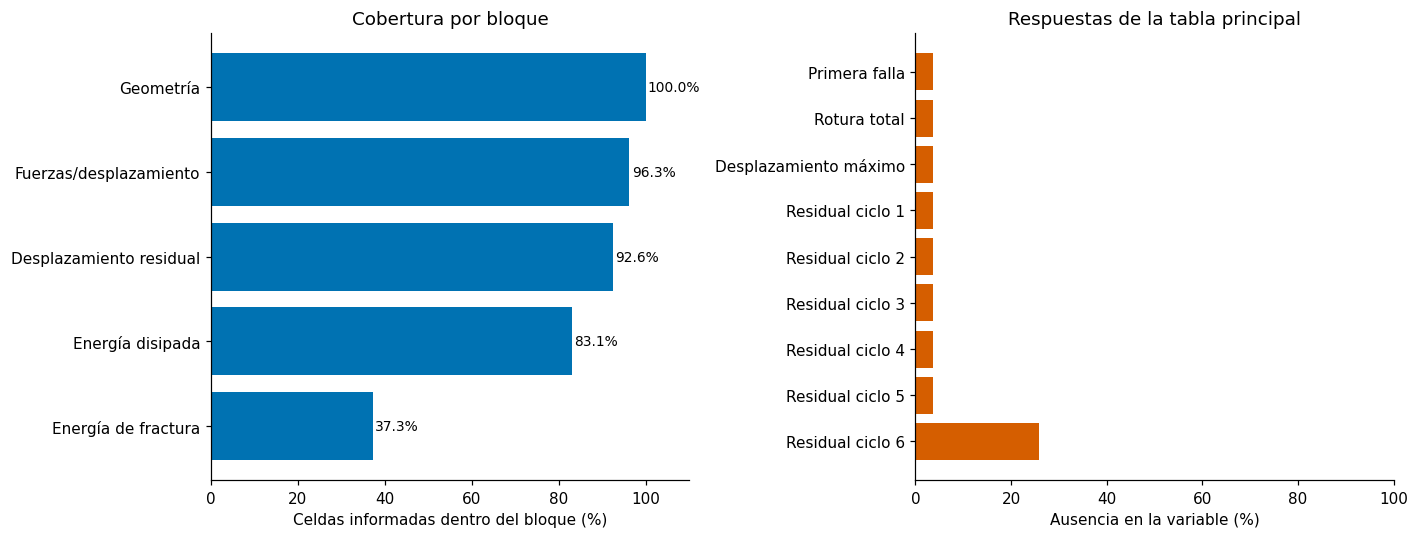

**FQ01 · Cobertura de mediciones. Pregunta:** ¿Qué bloques contienen ausencias? **Resultado:** La geometría está completa; el residual del ciclo 6 presenta 25.93% de ausencia. **Interpretación:** Las comparaciones mecánicas requieren denominadores propios. **Limitación:** La cobertura energética mezcla posiciones reservadas y ausencia documental; no es tasa de fallo instrumental. **Fuente:** archivo MATLAB de campaña. **Tabla:** `05_perfil_variables.csv`.

In [5]:
profile=table(profile_variables(all_values),"05_perfil_variables")
main_missing=source.drop(columns="Case_n").isna().mean().mul(100)
short={"First_Failure_Load_N":"Primera falla","Ultimate_Load":"Rotura total","Maximum_Displacement":"Desplazamiento máximo"}
short.update({c:f"Residual ciclo {i+1}" for i,c in enumerate(RESIDUAL)})
blocks=[GEOM,["First_Failure_Load_N","Ultimate_Load","Maximum_Displacement"],RESIDUAL,
        [c for c in all_values if c.startswith("Energy_Dissipated")],[c for c in all_values if c.startswith("Energy_Fracture")]]
coverage=[100*all_values[cols].notna().to_numpy().mean() for cols in blocks]
labels=["Geometría","Fuerzas/desplazamiento","Desplazamiento residual","Energía disipada","Energía de fractura"]
fig,axes=plt.subplots(1,2,figsize=(13,5))
axes[0].barh(labels[::-1],coverage[::-1],color="#0072B2")
axes[0].set(xlabel="Celdas informadas dentro del bloque (%)",xlim=(0,110),title="Cobertura por bloque")
for i,v in enumerate(coverage[::-1]): axes[0].text(v+.5,i,f"{v:.1f}%",va="center",fontsize=9)
m=main_missing.loc[main_missing>0]
axes[1].barh([short[c] for c in m.index][::-1],m.values[::-1],color="#D55E00")
axes[1].set(xlabel="Ausencia en la variable (%)",title="Respuestas de la tabla principal",xlim=(0,100))
figure(fig,"FQ01_completitud","FQ01 · Cobertura de mediciones","¿Qué bloques contienen ausencias?",
    f"La geometría está completa; el residual del ciclo 6 presenta {main_missing[RESIDUAL[-1]]:.2f}% de ausencia.",
    "Las comparaciones mecánicas requieren denominadores propios.",
    "La cobertura energética mezcla posiciones reservadas y ausencia documental; no es tasa de fallo instrumental.","05_perfil_variables")

## 1.6 Patrones de valores faltantes

Se comparan máscaras de ausencia por caso, ciclo y evento. La coausencia identifica mediciones que faltan conjuntamente; no determina la causa del faltante ni demuestra ausencia de ensayo.

Variables_ausentes,Frecuencia,Proporcion_%
ninguna,20,74.07
residual_Displacement_6cycle_60mm,6,22.22
First_Failure_Load_N; Ultimate_Load; Maximum_Displacement; residual_Displacement_1cycle_10mm; residual_Displacement_2cycle_20mm; residual_Displacement_3cycle_30mm; residual_Displacement_4cycle_40mm; residual_Displacement_5cycle_50mm; residual_Displacement_6cycle_60mm,1,3.704


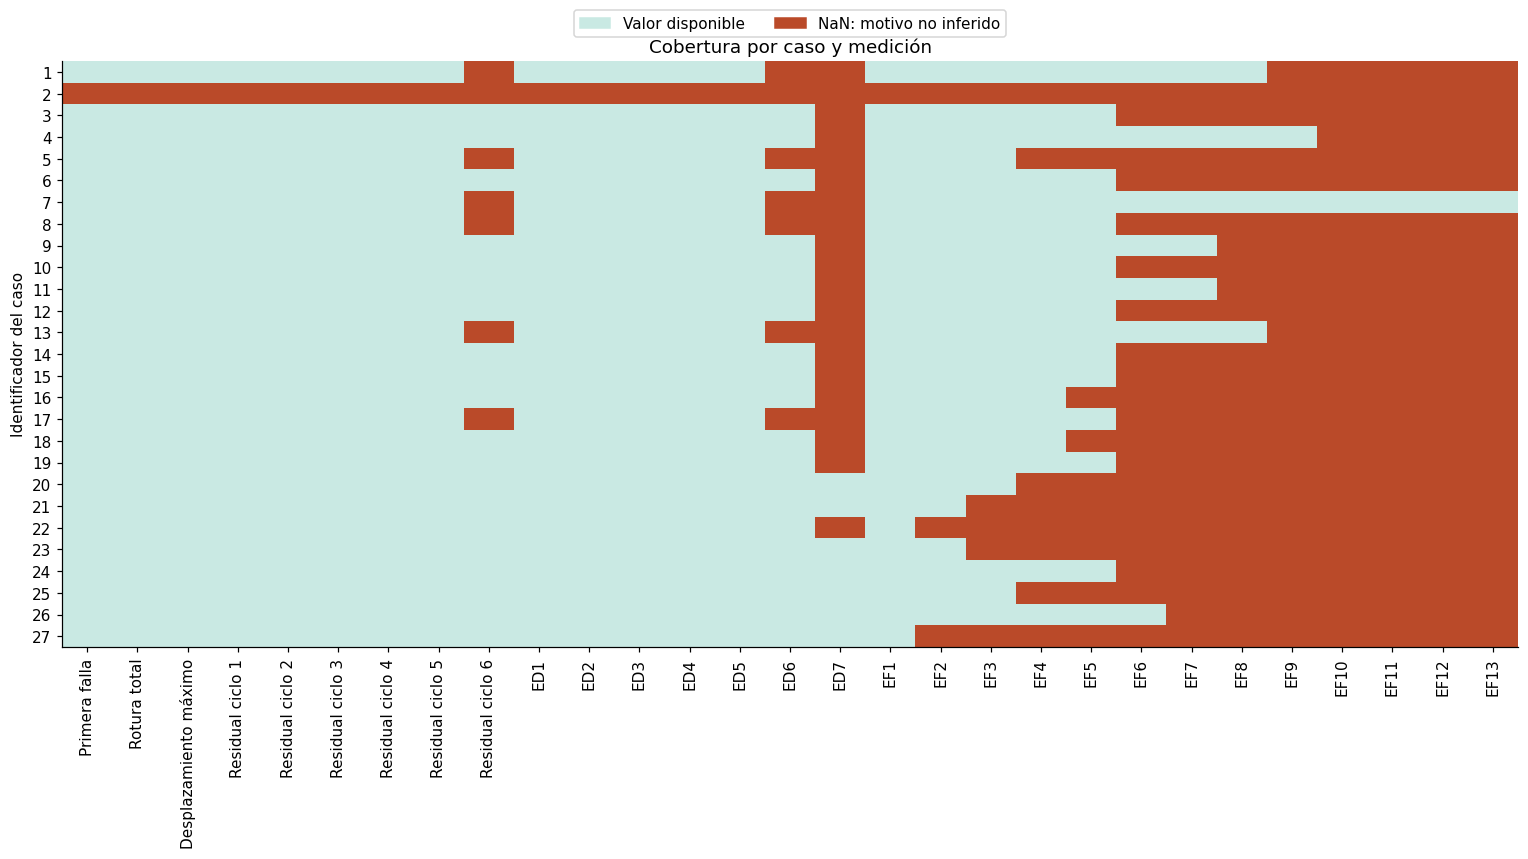

**FQ02 · Patrones conjuntos de ausencia. Pregunta:** ¿Qué respuestas faltan conjuntamente? **Resultado:** El caso 2 no contiene outputs; las ausencias del sexto residual y la sexta disipación coinciden caso por caso. **Interpretación:** Convertir NaN a cero modificaría trayectorias y asociaciones. **Limitación:** ED identifica ciclos de disipación y EF eventos de fractura; faltan motivos individuales de ausencia. **Fuente:** archivo MATLAB de campaña. **Tabla:** `06_patrones_samples.csv`.

In [6]:
responses_all=all_values.drop(columns=GEOM)
patterns_main=table(missing_patterns(source[RESPONSE]),"06_patrones_samples")
table(missing_patterns(energy_flat),"06_patrones_energia",show=False)
short_names=[short.get(c,c.replace("Energy_Dissipated__cycle_","ED").replace("Energy_Fracture__event_","EF")) for c in responses_all]
fig,ax=plt.subplots(figsize=(14,8))
ax.imshow(responses_all.isna().to_numpy(),aspect="auto",cmap=ListedColormap(["#c9e9e3","#ba4a29"]),vmin=0,vmax=1)
ax.set_xticks(range(len(short_names)),short_names,rotation=90)
ax.set_yticks(range(len(source)),source.Case_n.astype(int))
ax.set(ylabel="Identificador del caso",title="Cobertura por caso y medición")
ax.legend(handles=[Patch(color="#c9e9e3",label="Valor disponible"),Patch(color="#ba4a29",label="NaN: motivo no inferido")],
          loc="upper center",bbox_to_anchor=(.5,1.10),ncol=2)
coabsence=pd.DataFrame({"Case_n":source.Case_n,"Residual_6_ausente":source[RESIDUAL[-1]].isna(),
    "Disipacion_6_ausente":energies["Energy_Dissipated"].cycle_6.isna()})
assert coabsence.Residual_6_ausente.equals(coabsence.Disipacion_6_ausente)
table(coabsence,"06_coausencia",show=False)
figure(fig,"FQ02_mapa_ausencias","FQ02 · Patrones conjuntos de ausencia","¿Qué respuestas faltan conjuntamente?",
    "El caso 2 no contiene outputs; las ausencias del sexto residual y la sexta disipación coinciden caso por caso.",
    "Convertir NaN a cero modificaría trayectorias y asociaciones.",
    "ED identifica ciclos de disipación y EF eventos de fractura; faltan motivos individuales de ausencia.","06_patrones_samples")

## 1.7 Cobertura por familia y ciclo

Disponibilidad dentro de cada arquitectura y a lo largo de los ciclos. Las comparaciones longitudinales requieren una cohorte común para separar cambios de respuesta y cambios de composición.

Familia,Variable,Base_familia,Disponibles,Ausentes,Ausencia_%
4,residual_Displacement_6cycle_60mm,9,4,5,55.56
4,Energy_Dissipated__cycle_6,9,4,5,55.56
4,Energy_Dissipated__cycle_7,9,0,9,100
4,Energy_Fracture__event_5,9,7,2,22.22
5,residual_Displacement_6cycle_60mm,9,7,2,22.22
5,Energy_Dissipated__cycle_6,9,7,2,22.22
5,Energy_Dissipated__cycle_7,9,0,9,100
5,Energy_Fracture__event_5,9,7,2,22.22
6,residual_Displacement_6cycle_60mm,9,9,0,0
6,Energy_Dissipated__cycle_6,9,9,0,0


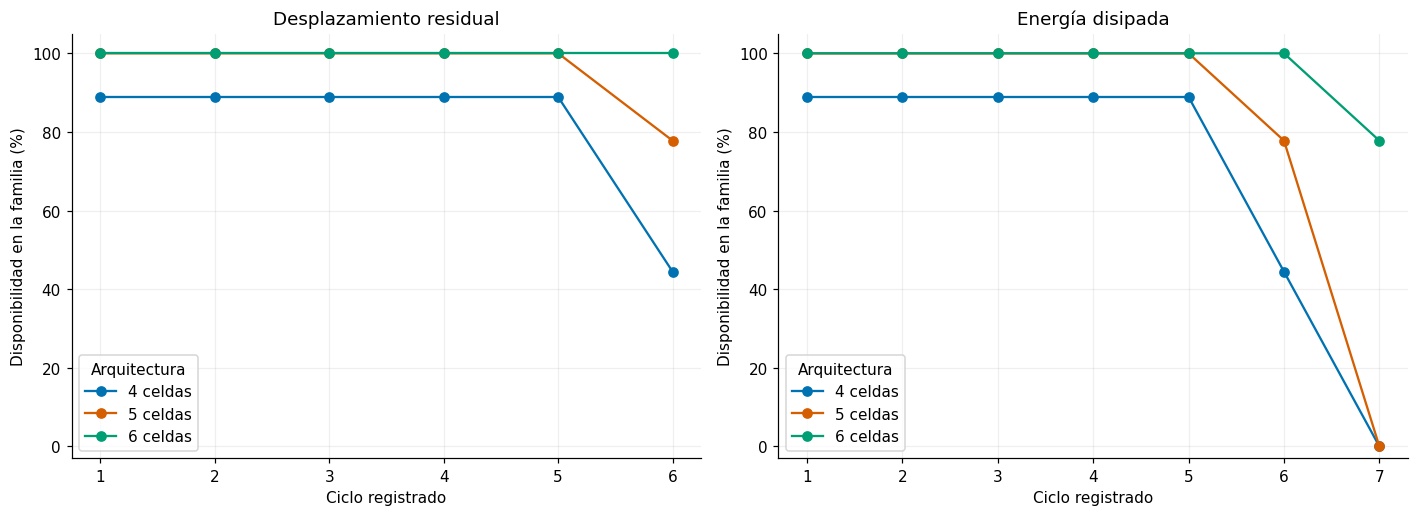

**FQ03 · Disponibilidad por ciclo y familia. Pregunta:** ¿La cobertura tardía es comparable? **Resultado:** El séptimo ciclo energético solo está informado para la familia de seis celdas; la cobertura del sexto varía por familia. **Interpretación:** Se debe distinguir evolución del mismo caso y selección de casos disponibles. **Limitación:** La ausencia no se atribuye a daño sin un motivo registrado. **Fuente:** archivo MATLAB de campaña. **Tabla:** `07_ausencia_familia.csv`.

In [7]:
group_missing=table(missing_by_group(responses_all,source.n_cells_Y),"07_ausencia_familia",show=False)
selected_cols=[RESIDUAL[-1],"Energy_Dissipated__cycle_6","Energy_Dissipated__cycle_7","Energy_Fracture__event_5"]
table(group_missing.loc[group_missing.Variable.isin(selected_cols)],"07_ausencia_familia_resumen")
fig,axes=plt.subplots(1,2,figsize=(13,4.8))
for family in sorted(source.n_cells_Y.unique()):
    selected=source.n_cells_Y.eq(family)
    axes[0].plot(range(1,7),source.loc[selected,RESIDUAL].notna().mean().mul(100),"o-",color=colors[int(family)],label=f"{int(family)} celdas")
    axes[1].plot(range(1,8),energies["Energy_Dissipated"].loc[selected].notna().mean().mul(100),"o-",color=colors[int(family)],label=f"{int(family)} celdas")
for ax,maximum,title in zip(axes,[6,7],["Desplazamiento residual","Energía disipada"]):
    ax.set(xlabel="Ciclo registrado",ylabel="Disponibilidad en la familia (%)",ylim=(-3,105),xticks=range(1,maximum+1),title=title)
    ax.grid(alpha=.2); ax.legend(title="Arquitectura")
figure(fig,"FQ03_cobertura_ciclos_familia","FQ03 · Disponibilidad por ciclo y familia","¿La cobertura tardía es comparable?",
    "El séptimo ciclo energético solo está informado para la familia de seis celdas; la cobertura del sexto varía por familia.",
    "Se debe distinguir evolución del mismo caso y selección de casos disponibles.",
    "La ausencia no se atribuye a daño sin un motivo registrado.","07_ausencia_familia")

## 1.8 Validación de dominios y signos

Controles de valores no finitos, dimensiones positivas, conteos enteros y residual/amplitud nominal. Se conservan los signos energéticos; no se aplica truncamiento ni valor absoluto sin justificar la convención de cálculo.

Variable,Disponibles,Ausentes,Ceros,Negativos,No_finitos,No_numericos
First_Failure_Load_N,26,1,0,0,0,0
Ultimate_Load,26,1,0,0,0,0
Maximum_Displacement,26,1,0,0,0,0
residual_Displacement_1cycle_10mm,26,1,0,0,0,0
residual_Displacement_2cycle_20mm,26,1,0,0,0,0
residual_Displacement_3cycle_30mm,26,1,0,0,0,0
residual_Displacement_4cycle_40mm,26,1,0,0,0,0
residual_Displacement_5cycle_50mm,26,1,0,0,0,0
residual_Displacement_6cycle_60mm,20,7,0,0,0,0
Energy_Dissipated__cycle_1,26,1,0,10,0,0


Control,Hallazgos
Geometría no positiva,0
Conteos no enteros,0
Primera falla no positiva,0
"Residual/amplitud fuera de [0,1]",0


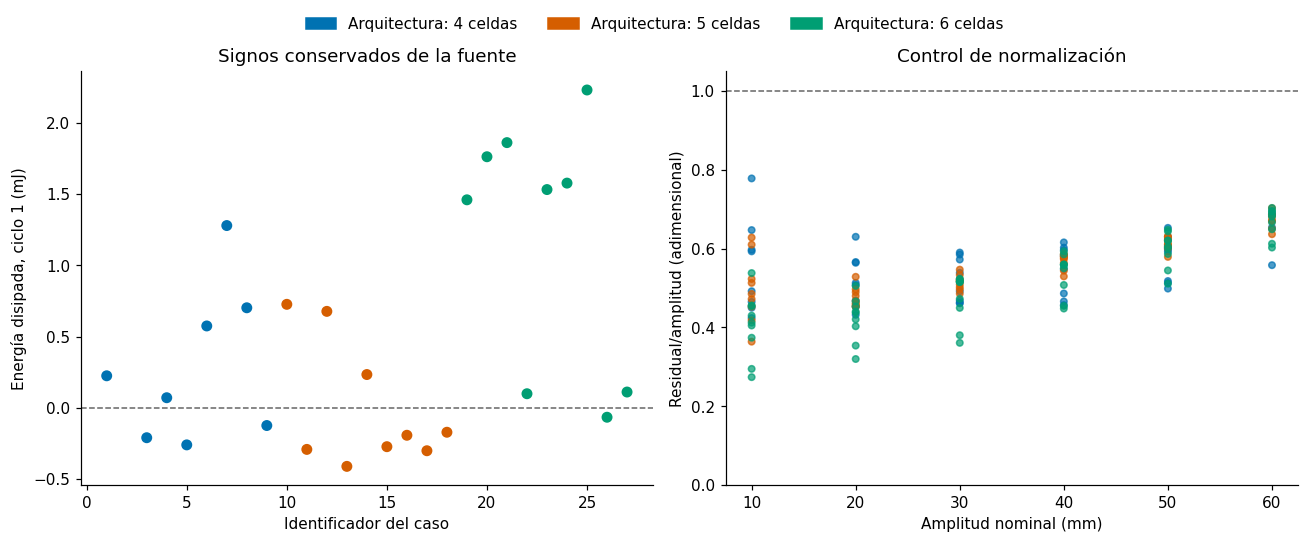

**FQ04 · Signos y coherencia nominal. Pregunta:** ¿Se distinguen signos y ausencia? **Resultado:** La energía inicial contiene negativos; los cocientes residuales observados están entre cero y uno. **Interpretación:** Preservar signos evita el sesgo por truncamiento; la fracción residual no es deformación axial unitaria. **Limitación:** La amplitud nominal no verifica calibración ni permite calcular tensión o rigidez. **Fuente:** archivo MATLAB de campaña. **Tabla:** `08_signos_y_nulos.csv`.

In [8]:
sign_table=table(profile.loc[(profile.Ausentes>0)|(profile.Ceros>0)|(profile.Negativos>0),
    ["Variable","Disponibles","Ausentes","Ceros","Negativos","No_finitos","No_numericos"]],"08_signos_y_nulos")
dissipated=energies["Energy_Dissipated"]
negative_cases=dissipated.index[dissipated.cycle_1<0].astype(int).tolist()
fraction=source[RESIDUAL].div(np.arange(10,70,10),axis=1)
domain=table(pd.DataFrame([
    ["Geometría no positiva",int((source[GEOM]<=0).sum().sum())],
    ["Conteos no enteros",int(((source[["n_cells_Y","Pivot_total_number"]]%1)!=0).sum().sum())],
    ["Primera falla no positiva",int((source.First_Failure_Load_N<=0).sum())],
    ["Residual/amplitud fuera de [0,1]",int(((fraction<0)|(fraction>1)).sum().sum())]],
    columns=["Control","Hallazgos"]),"08_dominios")
fig,axes=plt.subplots(1,2,figsize=(12,4.7))
axes[0].scatter(source.Case_n,dissipated.cycle_1,c=[colors[int(v)] for v in source.n_cells_Y],s=38)
axes[0].axhline(0,color="#666",ls="--",lw=1)
axes[0].set(xlabel="Identificador del caso",ylabel="Energía disipada, ciclo 1 (mJ)",title="Signos conservados de la fuente")
for c,amplitude in zip(RESIDUAL,range(10,70,10)):
    values=source[c].dropna()/amplitude
    axes[1].scatter(np.full(len(values),amplitude),values,s=18,c=[colors[int(v)] for v in source.loc[values.index,"n_cells_Y"]],alpha=.7)
axes[1].axhline(1,color="#666",ls="--",lw=1)
axes[1].set(xlabel="Amplitud nominal (mm)",ylabel="Residual/amplitud (adimensional)",title="Control de normalización",ylim=(0,1.05))
figure(fig,"FQ04_signos_normalizacion","FQ04 · Signos y coherencia nominal","¿Se distinguen signos y ausencia?",
    "La energía inicial contiene negativos; los cocientes residuales observados están entre cero y uno.",
    "Preservar signos evita el sesgo por truncamiento; la fracción residual no es deformación axial unitaria.",
    "La amplitud nominal no verifica calibración ni permite calcular tensión o rigidez.","08_signos_y_nulos")

## 1.9 Duplicados y cobertura de configuraciones

Detección de filas idénticas, columnas iguales y geometrías repetidas. Las coincidencias parciales de factores no acreditan réplicas; faltan identificadores de espécimen y lote para comprobar independencia experimental.

Tipo_de_repeticion,Frecuencia
Filas iguales con identificador,0
Filas iguales sin identificador,0
Columnas de contenido idéntico,0
Grupos de geometría completa repetida,0
Grupos de factores parciales repetidos,2


Nivel,Casos,Repeticiones,Geometria_que_difiere,Replica_confirmada
combinación parcial de factores,"19, 25",2,"Fiber_base, Fiber_total_volume, Pivot_total_volume, Sample_total_volume",No; falta identificación de espécimen y réplica
combinación parcial de factores,"24, 27",2,"Fiber_base, Sample_total_volume",No; falta identificación de espécimen y réplica


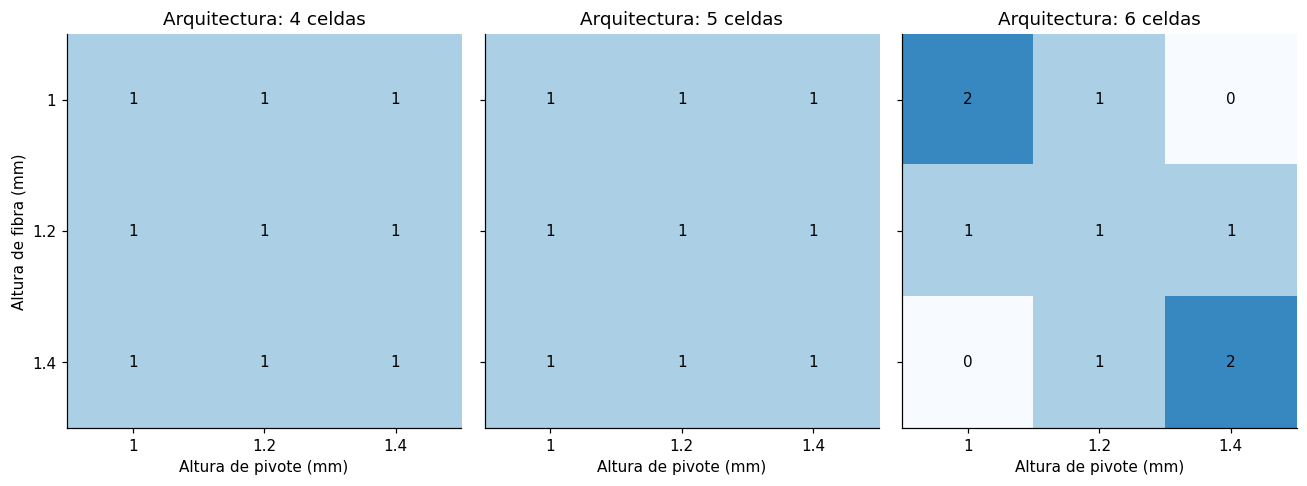

**FQ05 · Soporte de combinaciones geométricas. Pregunta:** ¿La rejilla está igualmente representada? **Resultado:** Las familias de cuatro y cinco celdas cubren la rejilla uniformemente; la de seis presenta huecos y factores parciales repetidos. **Interpretación:** La multiplicidad no prueba réplicas intercambiables ni autoriza promediar respuestas. **Limitación:** El mapa reproduce el MATLAB; las discrepancias con la tesis afectan parte de la familia de seis. **Fuente:** archivo MATLAB de campaña. **Tabla:** `09_cobertura_configuraciones.csv`.

In [9]:
config_repeats=configuration_audit(source.reset_index(drop=True),GEOM)
column_repeats=duplicate_columns(source.drop(columns="Case_n"))
duplicate_summary=table(pd.DataFrame([
    ["Filas iguales con identificador",int(source.reset_index(drop=True).duplicated().sum())],
    ["Filas iguales sin identificador",int(source.drop(columns="Case_n").duplicated().sum())],
    ["Columnas de contenido idéntico",len(column_repeats)],
    ["Grupos de geometría completa repetida",int(config_repeats.Nivel.eq("geometría registrada completa").sum())],
    ["Grupos de factores parciales repetidos",int(config_repeats.Nivel.eq("combinación parcial de factores").sum())]],
    columns=["Tipo_de_repeticion","Frecuencia"]),"09_duplicados_resumen")
table(config_repeats,"09_configuraciones_repetidas"); table(column_repeats,"09_columnas_iguales",show=False)
coverage_design=source.groupby(["n_cells_Y","Fiber_height","Pivot_height"]).size().rename("Casos_por_combinacion").reset_index()
table(coverage_design,"09_cobertura_configuraciones",show=False)
fig,axes=plt.subplots(1,3,figsize=(12,4.1),sharey=True)
for ax,family in zip(axes,sorted(source.n_cells_Y.unique())):
    matrix=coverage_design.loc[coverage_design.n_cells_Y.eq(family)].pivot(index="Fiber_height",columns="Pivot_height",values="Casos_por_combinacion").reindex(index=[1,1.2,1.4],columns=[1,1.2,1.4]).fillna(0)
    ax.imshow(matrix,cmap="Blues",vmin=0,vmax=3)
    for row in range(3):
        for col in range(3): ax.text(col,row,str(int(matrix.iloc[row,col])),ha="center",va="center",color="black")
    ax.set(xticks=range(3),xticklabels=[1,1.2,1.4],yticks=range(3),yticklabels=[1,1.2,1.4],xlabel="Altura de pivote (mm)",title=f"Arquitectura: {int(family)} celdas")
axes[0].set_ylabel("Altura de fibra (mm)")
figure(fig,"FQ05_cobertura_configuraciones","FQ05 · Soporte de combinaciones geométricas","¿La rejilla está igualmente representada?",
    "Las familias de cuatro y cinco celdas cubren la rejilla uniformemente; la de seis presenta huecos y factores parciales repetidos.",
    "La multiplicidad no prueba réplicas intercambiables ni autoriza promediar respuestas.",
    "El mapa reproduce el MATLAB; las discrepancias con la tesis afectan parte de la familia de seis.","09_cobertura_configuraciones")

## 1.10 Consistencia geométrica

Contraste con $V_{p}=N_p\pi r_p^2h_p$ y $V_f=L_f b_fh_f$: desviación $100(V_{registrado}/V_{ideal}-1)$. El umbral del 5 % señala revisión, no una tolerancia de fabricación. La suma de partes y el volumen CAD se mantienen como campos distintos.

Case_n,n_cells_Y,Fiber_total_volume,Pivot_total_volume,Sample_total_volume,V_pivote_ideal_mm3,V_fibra_ideal_mm3,Desviacion_pivote_%,Desviacion_fibra_%,Suma_volumenes_mm3,CAD_menos_suma_mm3,Revision_pivote_5pct,Revision_fibra_5pct
1,4,6435,88.71,6250,88.75,6446,-0.04506,-0.1655,6524,-274.3,False,False
2,4,6435,88.71,6149,88.75,6446,-0.04506,-0.1655,6524,-375.4,False,False
3,4,6435,88.71,6122,88.75,6430,-0.04506,0.08471,6524,-401.8,False,False
4,4,6418,106.5,6240,106.5,6419,-0.04694,-0.02414,6524,-283.8,False,False
5,4,6418,106.5,6170,106.5,6414,-0.04694,0.05959,6524,-353.8,False,False
6,4,6418,106.5,6140,106.5,6430,-0.04694,-0.1912,6524,-384.1,False,False
7,4,6400,124.2,6231,124.2,6392,-0.04828,0.1184,6524,-293.3,False,False
8,4,6400,124.2,6188,124.2,6414,-0.04828,-0.217,6524,-336,False,False
9,4,6400,124.2,6125,124.2,6392,-0.04828,0.1184,6524,-399.1,False,False
10,5,6390,134.3,6515,134.3,6389,-0.03208,0.01322,6524,-9.28,False,False


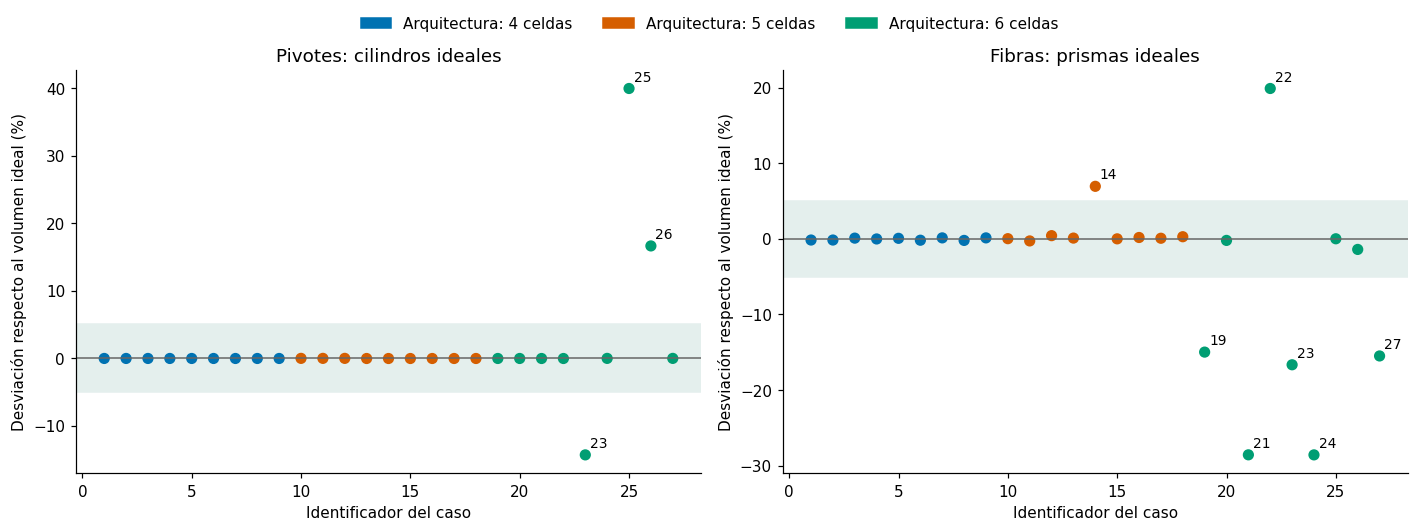

**FQ06 · Concordancia con idealizaciones geométricas. Pregunta:** ¿Qué valores requieren cotejo? **Resultado:** Los casos 23, 25, 26 superan la señal del 5 % en pivotes; la suma de partes declaradas es 6524.01 mm³. **Interpretación:** La diferencia puede reflejar geometría, definición o registro; se requiere contraste documental. **Limitación:** No se dispone de malla CAD ni tolerancia metrológica para validar una regla universal. **Fuente:** archivo MATLAB de campaña. **Tabla:** `10_consistencia_geometrica.csv`.

In [10]:
geometry_check=source[["Case_n","n_cells_Y","Fiber_total_volume","Pivot_total_volume","Sample_total_volume"]].copy()
geometry_check["V_pivote_ideal_mm3"]=source.Pivot_total_number*np.pi*source.Pivot_radius**2*source.Pivot_height
geometry_check["V_fibra_ideal_mm3"]=source.Fiber_total_length*source.Fiber_base*source.Fiber_height
geometry_check["Desviacion_pivote_%"]=100*(source.Pivot_total_volume/geometry_check.V_pivote_ideal_mm3-1)
geometry_check["Desviacion_fibra_%"]=100*(source.Fiber_total_volume/geometry_check.V_fibra_ideal_mm3-1)
geometry_check["Suma_volumenes_mm3"]=source.Fiber_total_volume+source.Pivot_total_volume
geometry_check["CAD_menos_suma_mm3"]=source.Sample_total_volume-geometry_check.Suma_volumenes_mm3
geometry_check["Revision_pivote_5pct"]=geometry_check["Desviacion_pivote_%"].abs()>5
geometry_check["Revision_fibra_5pct"]=geometry_check["Desviacion_fibra_%"].abs()>5
table(geometry_check.reset_index(drop=True),"10_consistencia_geometrica")
fig,axes=plt.subplots(1,2,figsize=(13,4.6))
for ax,var,title in zip(axes,["Desviacion_pivote_%","Desviacion_fibra_%"],["Pivotes: cilindros ideales","Fibras: prismas ideales"]):
    ax.scatter(source.Case_n,geometry_check[var],c=[colors[int(v)] for v in source.n_cells_Y],s=40)
    ax.axhline(0,color="#666",lw=1); ax.axhspan(-5,5,color="#e4efed",zorder=0)
    ax.set(xlabel="Identificador del caso",ylabel="Desviación respecto al volumen ideal (%)",title=title)
    for case,row in geometry_check.loc[geometry_check[var].abs()>5].iterrows():
        ax.annotate(str(int(case)),(case,row[var]),xytext=(3,5),textcoords="offset points",fontsize=9)
pivot_cases=geometry_check.index[geometry_check.Revision_pivote_5pct].astype(int).tolist()
fiber_cases=geometry_check.index[geometry_check.Revision_fibra_5pct].astype(int).tolist()
figure(fig,"FQ06_revision_volumenes","FQ06 · Concordancia con idealizaciones geométricas","¿Qué valores requieren cotejo?",
    "Los casos "+", ".join(map(str,pivot_cases))+" superan la señal del 5 % en pivotes; la suma de partes declaradas es "+f"{geometry_check.Suma_volumenes_mm3.median():.2f} mm³.",
    "La diferencia puede reflejar geometría, definición o registro; se requiere contraste documental.",
    "No se dispone de malla CAD ni tolerancia metrológica para validar una regla universal.","10_consistencia_geometrica")

## 1.11 Detección robusta de valores atípicos

Cercas IQR y puntuaciones MAD, globales y por familia. `MAD = 0` impide calcular la puntuación robusta; no demuestra ausencia de atípicos. Las alertas se conservan para el análisis de sensibilidad, sin eliminar observaciones.

Case_n,Variable,Grupo,Nivel,Valor,Bandera_IQR,Bandera_MAD,z_robusto
10,Ultimate_Load,global,Global,178.5,False,True,3.599
22,Ultimate_Load,global,Global,215.5,True,True,4.895
24,Ultimate_Load,global,Global,195.7,False,True,4.202
9,residual_Displacement_1cycle_10mm,global,Global,7.78,True,True,3.966
9,residual_Displacement_2cycle_20mm,global,Global,12.6,True,True,3.906
25,residual_Displacement_2cycle_20mm,global,Global,6.4,True,False,-3.367
25,residual_Displacement_3cycle_30mm,global,Global,10.83,True,True,-4.43
27,residual_Displacement_3cycle_30mm,global,Global,11.41,True,True,-3.875
7,residual_Displacement_4cycle_40mm,global,Global,18.27,True,False,-3.096
25,residual_Displacement_4cycle_40mm,global,Global,17.92,True,False,-3.354


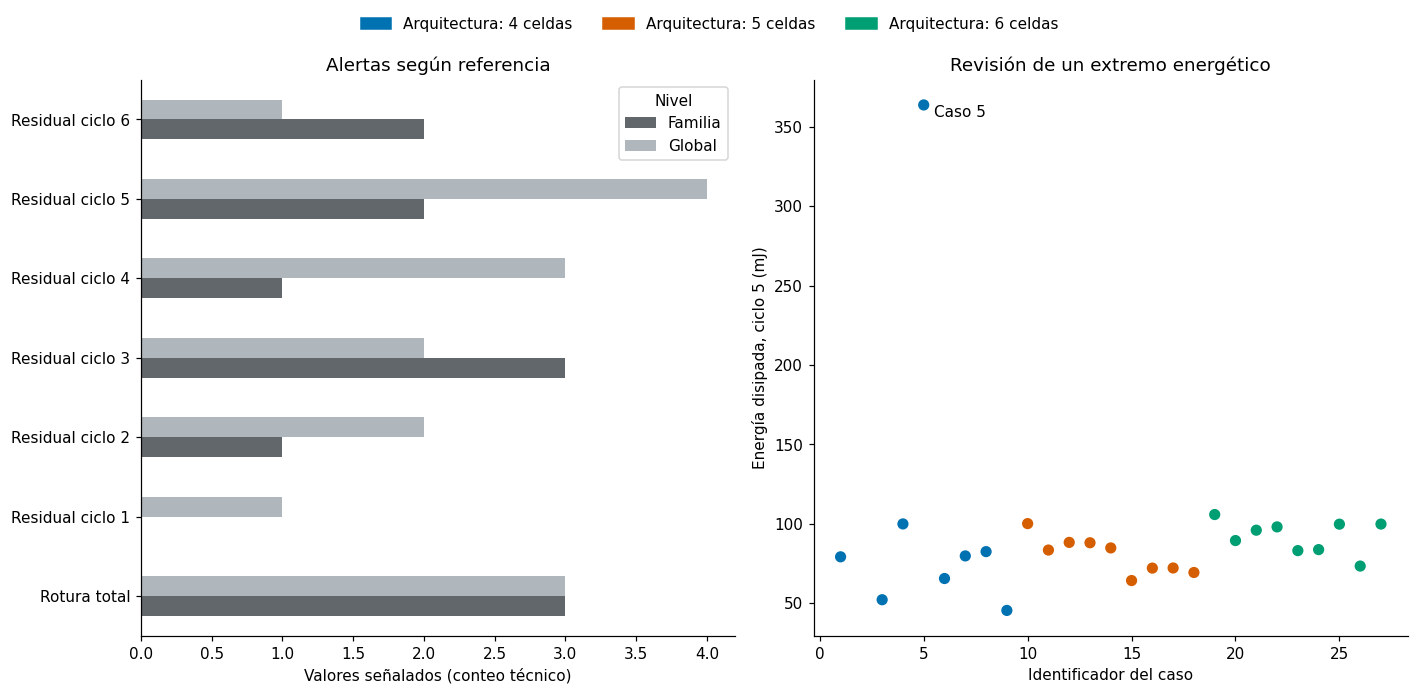

**FQ07 · Banderas robustas y extremo energético. Pregunta:** ¿Las alertas son errores confirmados? **Resultado:** La disipación del caso 5 en ciclo 5 es 363.8487 mJ; permanece disponible para sensibilidad. **Interpretación:** La bandera depende de escala y grupo; no establece invalidez experimental. **Limitación:** IQR/MAD pueden resultar poco informativos con empates o soporte discreto. **Fuente:** archivo MATLAB de campaña. **Tabla:** `11_alertas_robustas.csv`.

In [11]:
continuous=[c for c in [*GEOM,*RESPONSE] if c not in ["n_cells_Y","Pivot_total_number","Pivot_radius"]]
global_flags=robust_flags(source.reset_index(drop=True),continuous)
family_flags=robust_flags(source.reset_index(drop=True),continuous,group="n_cells_Y")
global_flags["Nivel"]="Global"; family_flags["Nivel"]="Familia"
flags=pd.concat([global_flags,family_flags],ignore_index=True)
flags["Cualquier_bandera"]=flags.Bandera_IQR|flags.Bandera_MAD.map(lambda x:bool(x) if pd.notna(x) else False)
table(flags,"11_diagnosticos_robustos",show=False)
flagged=flags.loc[flags.Cualquier_bandera,["Case_n","Variable","Grupo","Nivel","Valor","Bandera_IQR","Bandera_MAD","z_robusto"]]
table(flagged,"11_alertas_robustas")
flag_summary=flags.groupby(["Variable","Nivel"]).agg(Alertas=("Cualquier_bandera","sum"),Valores_evaluados=("Case_n","size"),
    MAD_no_calculable=("Bandera_MAD",lambda x:int(x.isna().sum()))).reset_index()
table(flag_summary,"11_alertas_resumen",show=False)
fig,axes=plt.subplots(1,2,figsize=(13,6))
a=flag_summary.pivot(index="Variable",columns="Nivel",values="Alertas").fillna(0)
a=a.loc[a.sum(axis=1)>0]
a.rename(index=short).plot.barh(ax=axes[0],color=["#62676c","#afb6bc"])
axes[0].set(ylabel="",xlabel="Valores señalados (conteo técnico)",title="Alertas según referencia")
axes[1].scatter(source.Case_n,dissipated.cycle_5,c=[colors[int(v)] for v in source.n_cells_Y],s=40)
axes[1].annotate("Caso 5",(5,dissipated.loc[5,"cycle_5"]),xytext=(7,-8),textcoords="offset points")
axes[1].set(xlabel="Identificador del caso",ylabel="Energía disipada, ciclo 5 (mJ)",title="Revisión de un extremo energético")
figure(fig,"FQ07_alertas_robustas","FQ07 · Banderas robustas y extremo energético","¿Las alertas son errores confirmados?",
    f"La disipación del caso 5 en ciclo 5 es {dissipated.loc[5,'cycle_5']:.4f} mJ; permanece disponible para sensibilidad.",
    "La bandera depende de escala y grupo; no establece invalidez experimental.",
    "IQR/MAD pueden resultar poco informativos con empates o soporte discreto.","11_alertas_robustas")

## 1.12 Disponibilidad de respuesta y composición

Comparación de mediana y rango de primera falla según disponibilidad del sexto residual, por familia. El resultado describe diferencias de composición; no identifica un mecanismo causal de ausencia.

Familia,Residual_6_disponible,Pares_con_fuerza,Mediana_N,Minimo_N,Maximo_N
4,False,4,65.44,47.55,74.02
4,True,4,74.75,61.43,88.5
5,False,2,83.55,75.71,91.39
5,True,7,103,91.8,114.3
6,False,0,—,—,—
6,True,9,205.3,191.4,215.5


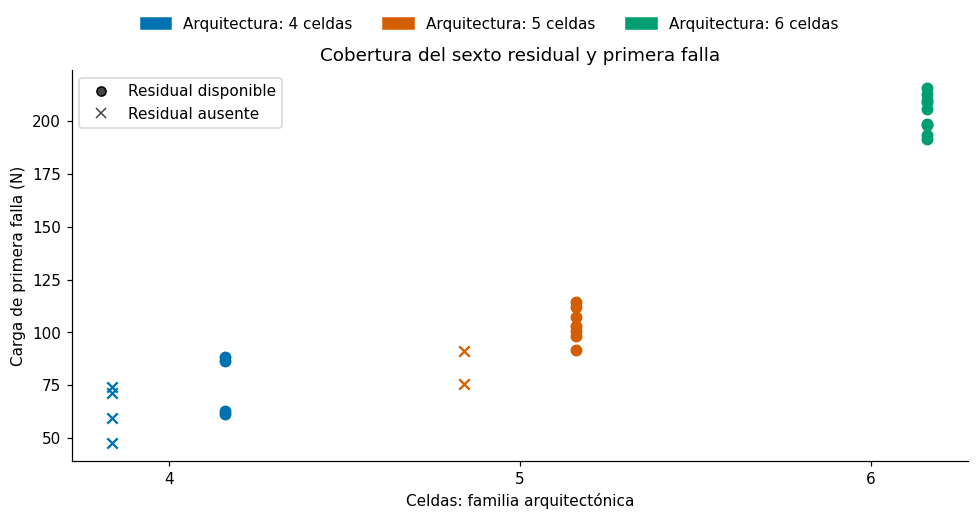

**FQ08 · Disponibilidad y composición experimental. Pregunta:** ¿La selección altera la composición? **Resultado:** La familia de seis celdas conserva cobertura del sexto residual; las ausencias con fuerza disponible están en las otras familias. **Interpretación:** La selección de casos disponibles puede confundirse con diferencias entre arquitecturas. **Limitación:** El patrón no demuestra un mecanismo de ausencia ni cuantifica sesgo causal. **Fuente:** archivo MATLAB de campaña. **Tabla:** `12_disponibilidad_y_fuerza.csv`.

In [12]:
availability_rows=[]
for family,group in source.groupby("n_cells_Y"):
    for available in [False,True]:
        values=group.loc[group[RESIDUAL[-1]].notna().eq(available),"First_Failure_Load_N"].dropna()
        availability_rows.append([int(family),available,len(values),values.median() if len(values) else np.nan,
                                  values.min() if len(values) else np.nan,values.max() if len(values) else np.nan])
availability=table(pd.DataFrame(availability_rows,columns=["Familia","Residual_6_disponible","Pares_con_fuerza","Mediana_N","Minimo_N","Maximo_N"]),"12_disponibilidad_y_fuerza")
fig,ax=plt.subplots(figsize=(9,4.5))
for family,group in source.groupby("n_cells_Y"):
    for available,offset in [(False,-.16),(True,.16)]:
        values=group.loc[group[RESIDUAL[-1]].notna().eq(available),"First_Failure_Load_N"].dropna()
        ax.scatter(np.full(len(values),family+offset),values,s=46,color=colors[int(family)],marker="o" if available else "x")
ax.set(xticks=[4,5,6],xlabel="Celdas: familia arquitectónica",ylabel="Carga de primera falla (N)",title="Cobertura del sexto residual y primera falla")
ax.legend(handles=[Line2D([0],[0],marker="o",color="none",markerfacecolor="#444",label="Residual disponible"),
                   Line2D([0],[0],marker="x",color="#444",ls="none",label="Residual ausente")])
figure(fig,"FQ08_disponibilidad_respuesta","FQ08 · Disponibilidad y composición experimental","¿La selección altera la composición?",
    "La familia de seis celdas conserva cobertura del sexto residual; las ausencias con fuerza disponible están en las otras familias.",
    "La selección de casos disponibles puede confundirse con diferencias entre arquitecturas.",
    "El patrón no demuestra un mecanismo de ausencia ni cuantifica sesgo causal.","12_disponibilidad_y_fuerza")

## 1.13 Registro de incidencias

Consolidación de variable afectada, evidencia, impacto y tratamiento. Se mantienen los valores originales y las discrepancias identificadas; una alerta de calidad no autoriza una corrección automática.

In [13]:
rows=[
["First_Failure_Load_N", "Resumen no idéntico a primer pico en algunas fichas", "Casos 3, 9, 12: resumen vs primer Upper Force; ver trazabilidad", "Selección operacional o redondeo por aclarar", "El evento exacto no se reconstruye solo del resumen", "Conservar target publicado; documentar discrepancia", "No sustituir el target por otro campo sin revisar protocolo"],
["Outputs del caso 2","Ausencia conjunta","Caso 2; comentario fuente: outputs por revisar","Problemas en outputs según fuente/apéndice","Sin objetivo observado para supervisión","Conservar geometría; excluir solo de análisis que requiere objetivo","No inventar respuesta ni afirmar ensayo inexistente"],
["Residual 6 / disipación 6","Coausencia","Máscaras idénticas por caso","Causa individual no documentada","Composición cambia entre ciclos","Contrastar cohorte común y pares disponibles","Separar trayectoria de selección"],
["Disipación ciclo 7","Cobertura por familia","Solo familia de seis celdas","Diseño o desarrollo; por confirmar","Sin comparación entre todas las familias","No imputar otros grupos","Ausencia no equivale a energía nula"],
["Energy_Fracture","Posiciones finales vacías","NaN y longitudes observadas variables","Posiciones reservadas o falta documental","Conteo observado no certifica todos los eventos","Usar secuencia observada; no NaN como cero","Evitar inventar energía total"],
["Disipación ciclo 1","Negativos","Casos: "+", ".join(map(str,negative_cases)),"Convención/procesamiento/resolución por verificar","Logaritmo directo no admisible en todos los valores","Preservar signos; cotejar curvas","Sin fundamento para truncar o usar valor absoluto"],
["Disipación ciclo 5","Extremo",f"Caso 5: {dissipated.loc[5,'cycle_5']:.4f} mJ","Respuesta real o incidencia no resuelta","Influencia en resúmenes/asociaciones","Conservar y evaluar sensibilidad","Extremo no demuestra error"],
["Fiber_base","Selección histórica distinta","Snapshot la incluye; esquema actual la excluye","Evolución de configuración","Reproducir con otro esquema cambia columnas","Mantener ambos estados; EDA usa columna existente","Selección no equivale a inexistencia"],
["Pivot_radius","Constante","Radio único: 0.5 mm","Diseño sin variación de radio","No se estima asociación ni efecto del radio","Conservar; excluir del ajuste por varianza nula","No confundir falta de variación con falta de efecto"],
["Volumen/altura de pivotes","Desviación de cilindro ideal","Casos: "+", ".join(map(str,pivot_cases)),"Definición o registro; diferencias PDF–MATLAB","Afecta variables derivadas","Señalar y contrastar sensibilidad","5 % no es tolerancia metrológica"],
["Fiber_base / Pivot_height","Diferencia PDF–MATLAB","Caso 14: base PDF 1.66 mm vs MATLAB 1.56 mm; alturas de pivote: casos 21, 23, 24, 25, 26","Versión/transcripción no resuelta","Geometría documental no unívoca","Conservar .m y cotejo por página","No elegir una fuente como verdad sin validación"],
["Fichas de tesis","Campos geométricos desplazados","Casos 5, 12, 13; ver trazabilidad","Maquetación/etiquetado","La corrección automática con PDF puede ser errónea","Revisión por variable y caso","El PDF también requiere contraste"],
["V_fibras + V_pivotes","Identidad algebraica",f"Suma {geometry_check.Suma_volumenes_mm3.median():.2f} mm³","Restricción del diseño/construcción de campos","Redundancia determinística","Controlar selección conjunta","No atribuir efectos independientes"],
["Sample_total_volume","CAD distinto de suma","Diferencia CAD−suma variable","Definición CAD/intersecciones; por cotejar","Normalizaciones pueden confundirse","Mantener definiciones diferenciadas","Suma de partes no reemplaza volumen CAD"],
["Factores parciales repetidos","Réplica no acreditada","Tabla 09_configuraciones_repetidas","Otras dimensiones difieren","Dependencia no completamente documentada","No promediar ni multiplicar unidades por ciclo","Faltan espécimen/lote/réplica"],
["Ultimate_Load","Respuesta de rotura total","Puede ser menor que primera falla; tesis cap.9","Daño progresivo compatible, no probado por agregados","Confundir con máximo crea falsas incoherencias","Tratar como output posterior","No reconstruir curvas a partir de agregados"],
["Energías","Unidad no indicada en .m","mJ en fichas PDF 117/121","Metadatos omitidos en script","Posibles etiquetas/conversiones erróneas","Registrar mJ con fuente; sin modificar valores","Unidad documental, no inferida de magnitud"],
["Manifiestos preliminary","Ruta histórica","Hash válido; ruta de corrida original","Copia de snapshot","Ubicación actual diferente","Separar ubicación y procedencia","Integridad no exige ruta idéntica"],
]
decisions=table(pd.DataFrame(rows,columns=["Variable","Problema","Evidencia","Posible causa","Impacto","Tratamiento","Justificación"]),"14_decisiones")

Variable,Problema,Evidencia,Posible causa,Impacto,Tratamiento,Justificación
First_Failure_Load_N,Resumen no idéntico a primer pico en algunas fichas,"Casos 3, 9, 12: resumen vs primer Upper Force; ver trazabilidad",Selección operacional o redondeo por aclarar,El evento exacto no se reconstruye solo del resumen,Conservar target publicado; documentar discrepancia,No sustituir el target por otro campo sin revisar protocolo
Outputs del caso 2,Ausencia conjunta,Caso 2; comentario fuente: outputs por revisar,Problemas en outputs según fuente/apéndice,Sin objetivo observado para supervisión,Conservar geometría; excluir solo de análisis que requiere objetivo,No inventar respuesta ni afirmar ensayo inexistente
Residual 6 / disipación 6,Coausencia,Máscaras idénticas por caso,Causa individual no documentada,Composición cambia entre ciclos,Contrastar cohorte común y pares disponibles,Separar trayectoria de selección
Disipación ciclo 7,Cobertura por familia,Solo familia de seis celdas,Diseño o desarrollo; por confirmar,Sin comparación entre todas las familias,No imputar otros grupos,Ausencia no equivale a energía nula
Energy_Fracture,Posiciones finales vacías,NaN y longitudes observadas variables,Posiciones reservadas o falta documental,Conteo observado no certifica todos los eventos,Usar secuencia observada; no NaN como cero,Evitar inventar energía total
Disipación ciclo 1,Negativos,"Casos: 3, 5, 9, 11, 13, 15, 16, 17, 18, 26",Convención/procesamiento/resolución por verificar,Logaritmo directo no admisible en todos los valores,Preservar signos; cotejar curvas,Sin fundamento para truncar o usar valor absoluto
Disipación ciclo 5,Extremo,Caso 5: 363.8487 mJ,Respuesta real o incidencia no resuelta,Influencia en resúmenes/asociaciones,Conservar y evaluar sensibilidad,Extremo no demuestra error
Fiber_base,Selección histórica distinta,Snapshot la incluye; esquema actual la excluye,Evolución de configuración,Reproducir con otro esquema cambia columnas,Mantener ambos estados; EDA usa columna existente,Selección no equivale a inexistencia
Pivot_radius,Constante,Radio único: 0.5 mm,Diseño sin variación de radio,No se estima asociación ni efecto del radio,Conservar; excluir del ajuste por varianza nula,No confundir falta de variación con falta de efecto
Volumen/altura de pivotes,Desviación de cilindro ideal,"Casos: 23, 25, 26",Definición o registro; diferencias PDF–MATLAB,Afecta variables derivadas,Señalar y contrastar sensibilidad,5 % no es tolerancia metrológica


## 1.14 Interpretación de resultados y validación final

La extracción y la reconstrucción histórica coinciden con las tablas preliminares; el esquema actual difiere en la selección de `Fiber_base`. La geometría está completa, mientras la disponibilidad de respuestas cambia entre ciclos y familias. No se eliminaron valores atípicos ni se imputaron respuestas.

Los controles verifican integridad digital y consistencia interna. Las discrepancias geométricas, la independencia de réplicas y las causas de ausencia requieren información adicional. Las curvas y la precisión instrumental no se pueden validar con estos agregados.

In [14]:
after_hashes={p.relative_to(ROOT).as_posix():sha256_file(p) for p in protected}
assert before_hashes==after_hashes,"Cambió un archivo protegido durante el notebook"
validation=table(pd.DataFrame([
    ["Literales MATLAB completos",bool(literal_audit.Valores_y_NaN_coinciden.all())],
    ["Fuente vs snapshot interim",comparisons["MATLAB vs interim preliminary"].empty],
    ["Fuente vs nueva ingesta",comparisons["MATLAB vs nueva ingesta"].empty],
    ["Curaduría histórica reproducida",comparisons["Curaduría histórica reproducida vs snapshot"].empty],
    ["Nombres e identificadores no ambiguos",bool(name_checks.Hallazgos.eq(0).all())],
    ["Fuentes y snapshots sin cambios",before_hashes==after_hashes]],columns=["Comprobacion","Superada"]),"15_validacion")
assert validation.Superada.all()
manifest={"source_sha256":before_hashes,"protected_files_unchanged":True,
    "new_ingestion":ingestion["interim_file"],"new_curation":current_quality["output_file"],
    "python":platform.python_version(),"numpy":np.__version__,"pandas":pd.__version__,
    "figures":fig_meta,"tables":sorted(p.name for p in TABLES.glob("*.csv")),
    "artifacts_sha256":{p.relative_to(OUT).as_posix():sha256_file(p) for p in sorted(OUT.rglob("*")) if p.is_file() and p.name!="manifest.json"}}
(OUT/"manifest.json").write_text(json.dumps(manifest,indent=2,ensure_ascii=False),encoding="utf-8")

def markdown_table(frame):
    lines=["| "+" | ".join(frame.columns)+" |","| "+" | ".join(["---"]*len(frame.columns))+" |"]
    lines.extend("| "+" | ".join(str(v).replace("|","/") for v in row)+" |" for row in frame.itertuples(index=False,name=None))
    return chr(10).join(lines)
report=["# Informe de curaduría y calidad experimental","",
    "**Universidad Nacional de Ingeniería · FIIS · Maestría en Inteligencia Artificial**  ",
    "**Trabajo de Investigación II · MIA, 4.º ciclo, sección B · 2026-2**  ",
    "**Docente:** Glen Dario Rodríguez Rafael  ","**Investigadora:** Melissa Dessire Aylas Barranca","",
    "## Propósito y alcance","",
    "La auditoría evalúa extracción MATLAB–Python, disponibilidad de mediciones y consistencia de geometría y respuestas pantográficas. La carga de primera falla es el objetivo predictivo futuro. No se imputan objetivos ni se confunden respuestas medidas en el ensayo con entradas previas. La fidelidad digital y la concordancia documental son verificaciones diferentes.","",
    "La fuente digital es `data/raw/dati_campagna_venditti.m`. El [fundamento](introduccion_experimento.md), el [diccionario](diccionario_datos.md) y la [trazabilidad](trazabilidad_datos.md) contienen definiciones, unidades y discrepancias. Las dimensiones exteriores documentadas son 210 × 70 mm: la familia de celdas indica arquitectura, no aumento demostrado del tamaño exterior.","",
    "## Integridad y reproducción","",
    "La ingesta y curaduría se ejecutaron en nuevos directorios fechados. Las fuentes, los snapshots preliminary y el esquema se conservaron intactos, con hashes antes/después. La comprobación independiente verificó valores y NaN de todos los vectores; la reconstrucción con el esquema histórico coincide con el snapshot procesado. El esquema actual omite Fiber_base, presente en fuente y snapshot histórico: diferencia de selección, no pérdida de información.","",
    "Los hashes de los snapshots coinciden con sus manifiestos; las rutas internas describen corridas históricas. Se registra la ubicación actual sin reescribir la procedencia. Véase [comparación ejecutada](../reports/eda_calidad/tables/03_equivalencia.csv).","",
    "## Completitud y dependencia","",
    f"La geometría está completa. El residual del sexto ciclo presenta {main_missing[RESIDUAL[-1]]:.2f}% de ausencia; su máscara coincide con la sexta disipación. El caso 2 carece de outputs, que la fuente indica deben revisarse. No se interpreta como fuerza cero ni como ensayo inexistente.","",
    "La cobertura del séptimo ciclo energético está concentrada en la familia de seis celdas. Comparar valores disponibles de ciclos distintos puede cambiar la composición; se requiere cohorte común. Los motivos individuales no permiten certificar mecanismos MCAR, MAR o MNAR. Las posiciones vacías de fractura pueden estar reservadas o carecer de medición: el caso 5 tiene un cuarto evento en la tabla de picos (PDF 129), pero su energía es NaN (PDF 131). El número de energías observadas no equivale al número total de fracturas.","",
    "![Cobertura](../reports/eda_calidad/figures/FQ01_completitud.png)","",
    "![Ausencias](../reports/eda_calidad/figures/FQ02_mapa_ausencias.png)","",
    "![Cobertura longitudinal](../reports/eda_calidad/figures/FQ03_cobertura_ciclos_familia.png)","",
    "## Configuraciones y réplicas","",
    "No se detectaron filas exactamente duplicadas, identificadores repetidos ni columnas numéricamente idénticas. Repetir factores parciales no acredita geometría completa idéntica ni réplicas. La familia de seis celdas presenta cobertura no uniforme en la rejilla de alturas del MATLAB; discrepancias con la tesis afectan parte de esa familia. Ciclos y eventos pertenecen al mismo caso y no son nuevas unidades experimentales independientes.","",
    "![Configuraciones](../reports/eda_calidad/figures/FQ05_cobertura_configuraciones.png)","",
    "## Consistencia geométrica, signos y extremos","",
    f"La suma de volúmenes declarados de fibras y pivotes es {geometry_check.Suma_volumenes_mm3.median():.2f} mm³: dependencia algebraica que no equivale automáticamente al volumen CAD. El contraste cilíndrico señala los casos {', '.join(map(str,pivot_cases))}; la idealización prismática también presenta diferencias. El 5 % se usa para inspección, no como tolerancia experimental validada.","",
    f"Se preservan negativos de energía inicial y el extremo del caso 5, ciclo 5 ({dissipated.loc[5,'cycle_5']:.4f} mJ). No se aplicó eliminación por IQR/MAD, truncamiento ni relleno con ceros. La unidad mJ está verificada en fichas PDF 117/121, no inferida a partir de magnitudes.","",
    "![Control geométrico](../reports/eda_calidad/figures/FQ06_revision_volumenes.png)","",
    "![Anomalías robustas](../reports/eda_calidad/figures/FQ07_alertas_robustas.png)","",
    "## Decisiones justificadas","",markdown_table(decisions),"",
    "## Limitaciones y requerimientos experimentales","",
    "Faltan identidad física de especímenes/réplicas, lotes, causas individuales de ausencia y resolución de diferencias documentales. Algunas fichas PDF contienen campos desplazados; no se usaron como reemplazo automático del MATLAB. Curvas numéricas son necesarias para rigidez o integración energética. Los agregados no justifican reconstruir histéresis ni confirmar mecanismos. Verificar importación no certifica calibración ni causalidad.","",
    "## Reproducción y evidencias","","```powershell","python -m src.eda_calidad --execute","```","",
    "[Notebook ejecutado](../notebooks/01_Ingesta_Curaduria_y_Calidad.ipynb) · [HTML](../reports/01_Ingesta_Curaduria_y_Calidad.html) · [Manifiesto](../reports/eda_calidad/manifest.json) · [Decisiones CSV](../reports/eda_calidad/tables/14_decisiones.csv)","",
    "Las figuras se exportan en PNG a 320 dpi y SVG. Las tablas incluyen tamaños efectivos pertinentes, sin hacer del total global el eje de la narrativa. No se entrenaron modelos en esta auditoría."]
(ROOT/"docs/informe_curaduria.md").write_text(chr(10).join(report)+chr(10),encoding="utf-8")
print("Auditoría finalizada: figuras PNG/SVG, tablas, informe y manifiesto; archivos protegidos intactos.")

Comprobacion,Superada
Literales MATLAB completos,True
Fuente vs snapshot interim,True
Fuente vs nueva ingesta,True
Curaduría histórica reproducida,True
Nombres e identificadores no ambiguos,True
Fuentes y snapshots sin cambios,True


Auditoría finalizada: figuras PNG/SVG, tablas, informe y manifiesto; archivos protegidos intactos.
